In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df=pd.read_csv('../diabetes2.csv')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [33]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
X.shape

(768, 8)

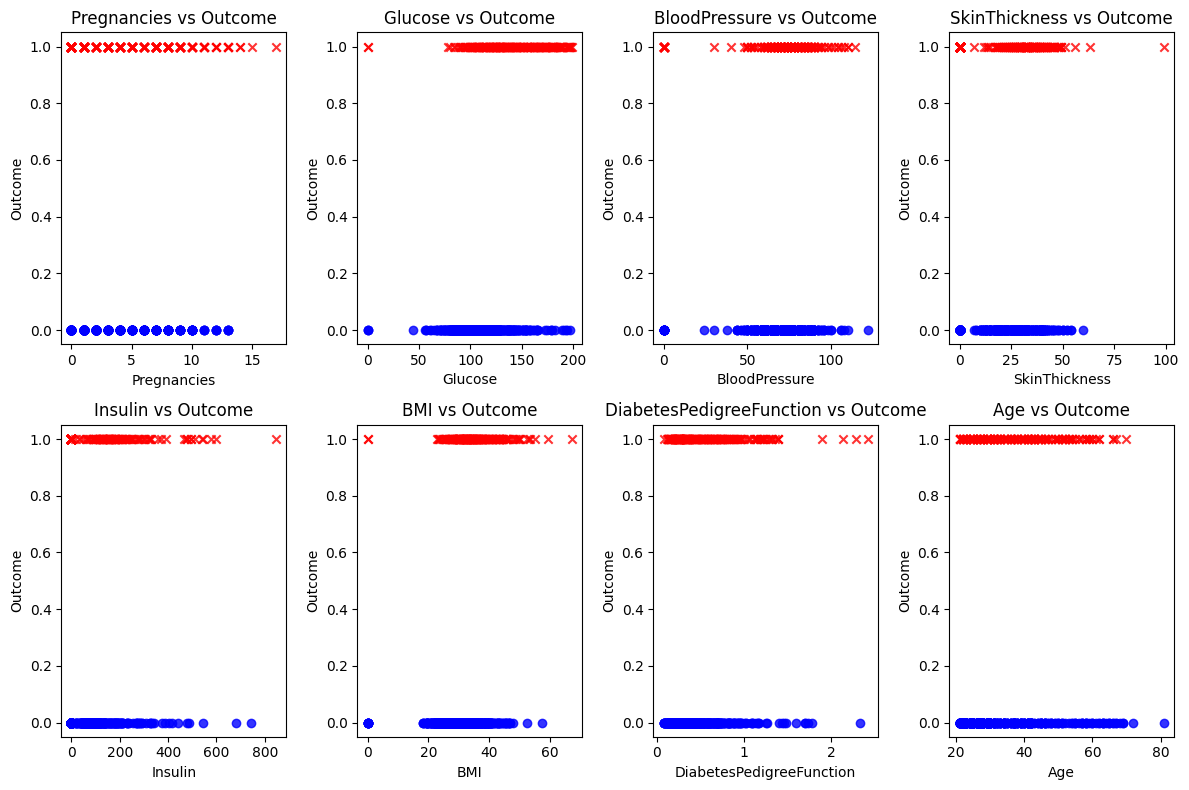

In [34]:
fig,axes=plt.subplots(2,4,figsize=(12,8))
axes=axes.flatten()

for i in range(8):
    axes[i].scatter(X[y==0,i],y[y==0],alpha=0.8,color='blue',marker='o')
    axes[i].scatter(X[y==1,i],y[y==1],alpha=0.8,color='red',marker='x')
    axes[i].set_title(f"{df.columns[i]} vs {df.columns[-1]}")
    axes[i].set_xlabel(f"{df.columns[i]}")
    axes[i].set_ylabel(f"{df.columns[-1]}")
plt.tight_layout()
plt.show()

In [35]:
def mean(x):
    return np.sum(x)/len(x)
def variance(x):
    return np.sum((x-mean(x))**2)/len(x)
def zscore(x):
    return (x-mean(x))/np.sqrt(variance(x))
n=X.shape[1]
for i in range(n):
    X[:,i]=zscore(X[:,i])

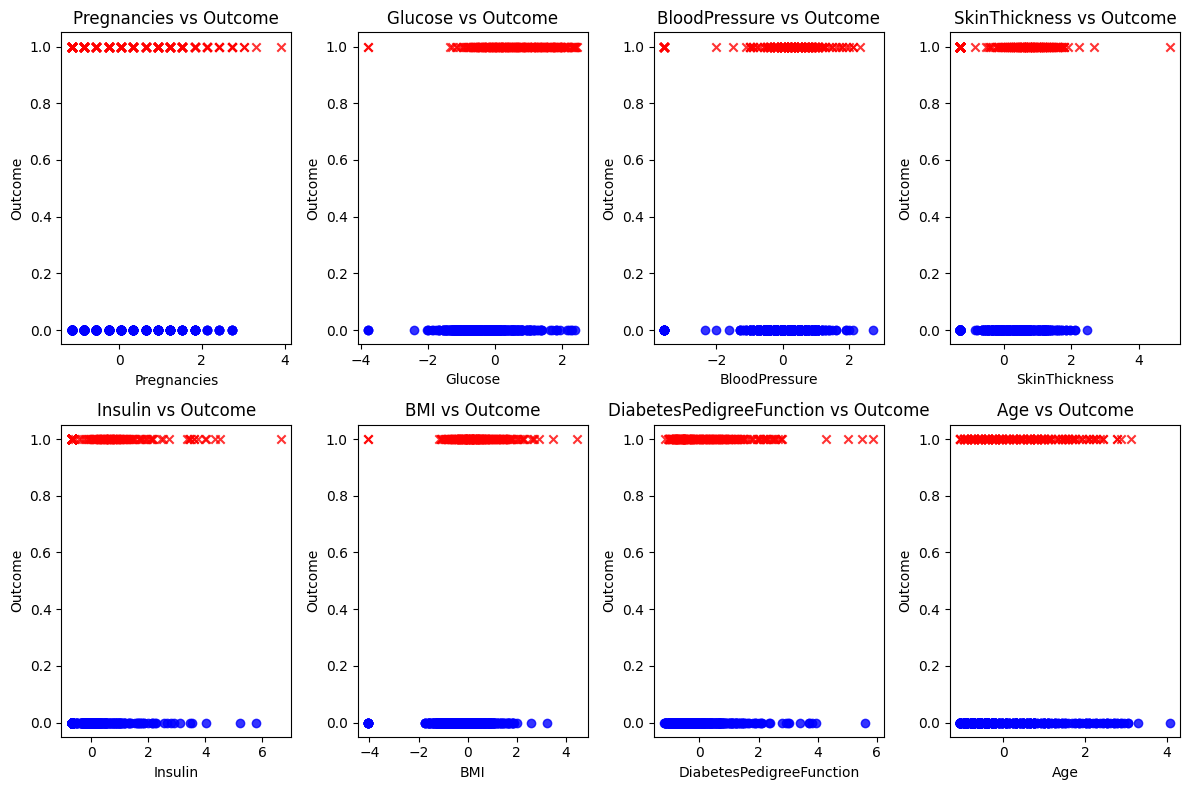

In [36]:
fig,axes=plt.subplots(2,4,figsize=(12,8))
axes=axes.flatten()

for i in range(8):
    axes[i].scatter(X[y==0,i],y[y==0],alpha=0.8,color='blue',marker='o')
    axes[i].scatter(X[y==1,i],y[y==1],alpha=0.8,color='red',marker='x')
    axes[i].set_title(f"{df.columns[i]} vs {df.columns[-1]}")
    axes[i].set_xlabel(f"{df.columns[i]}")
    axes[i].set_ylabel(f"{df.columns[-1]}")
plt.tight_layout()
plt.show()

In [59]:
class logistic_regression:
    def __init__(self,alpha=0.1,max_iter=2000,threshold=1e-6):
        self.alpha=alpha
        self.max_iter=max_iter
        self.threshold=threshold
        self.weight=np.random.uniform(-1,1,8)
        self.bias=np.random.uniform(-1,1)
    def lr(self,x):
        return np.dot(self.weight,x)+self.bias
    def sig(self,x):
        return 1/(1+np.exp(-self.lr(x)))
    def compute_cost(self,X,y):
        m=X.shape[0]
        cost=0
        for i in range(m):
            p=np.clip(self.sig(X[i]),1e-10,1-1e-10)
            loss=(y[i])*(np.log(p))+(1-y[i])*(np.log(1-p))
            cost+=loss
        cost/=(-m)
        return cost
    def compute_gradient(self,X,y,j):
        m=X.shape[0]
        grad=0
        for i in range(m):
            error=(self.sig(X[i])-y[i])
            if (j!=-1):
                error*=X[i,j]
            grad+=error
        grad/=m
        return grad
    def gradient_descent(self,X,y):
        m,n=X.shape
        cost_history=[]
        prev_cost=self.compute_cost(X,y)
        cost_history.append(prev_cost)
        for k in range(self.max_iter):
            temp_w=np.zeros(n)
            temp_b=0
            for j in range(n):
                temp_w[j]=self.weight[j]-self.alpha*self.compute_gradient(X,y,j)
            temp_b=self.bias-self.alpha*self.compute_gradient(X,y,-1)
            self.weight=temp_w
            self.bias=temp_b
            current_cost=self.compute_cost(X,y)
            cost_history.append(current_cost)
            if abs(prev_cost-current_cost)<self.threshold:
                break
            prev_cost=current_cost
        return cost_history
    def predict(self,x):
        z=np.dot(x,self.weight)+self.bias
        return 1/(1+np.exp(-z))
    def plot_cost(self,cost):
        plt.plot(cost)
        return
    def plot_model(self,X,y,feature_names):
        fig,axes=plt.subplots(2,4,figsize=(12,8))
        axes=axes.flatten()
        n=X.shape[1]
        for i in range(n):
            axes[i].scatter(X[y==0,i],y[y==0],alpha=0.8,color='blue',marker='o')
            axes[i].scatter(X[y==1,i],y[y==1],alpha=0.8,color='red',marker='x')
            x_range=np.linspace(X[:,i].min(),X[:,i].max(),100)
            X_temp=np.zeros((100,n))
            X_temp[:,i]=x_range
            z=np.dot(X_temp,self.weight)+self.bias
            prob=1/(1+np.exp(-z))
            axes[i].plot(x_range,prob,linewidth=2,color='orange')
            axes[i].set_title(f"{feature_names[i]} vs {feature_names[-1]}")
            axes[i].set_xlabel(f"{feature_names[i]}")
            axes[i].set_ylabel(f"{feature_names[-1]}")
        plt.tight_layout()
        plt.show()

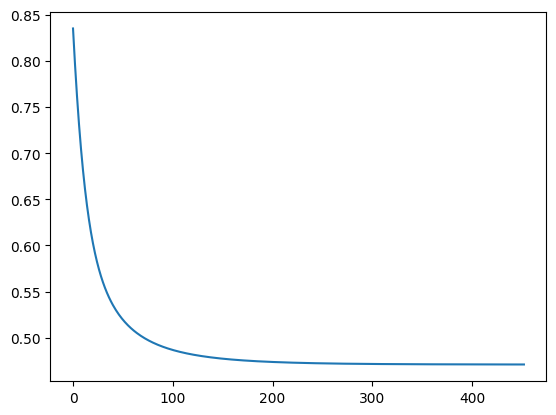

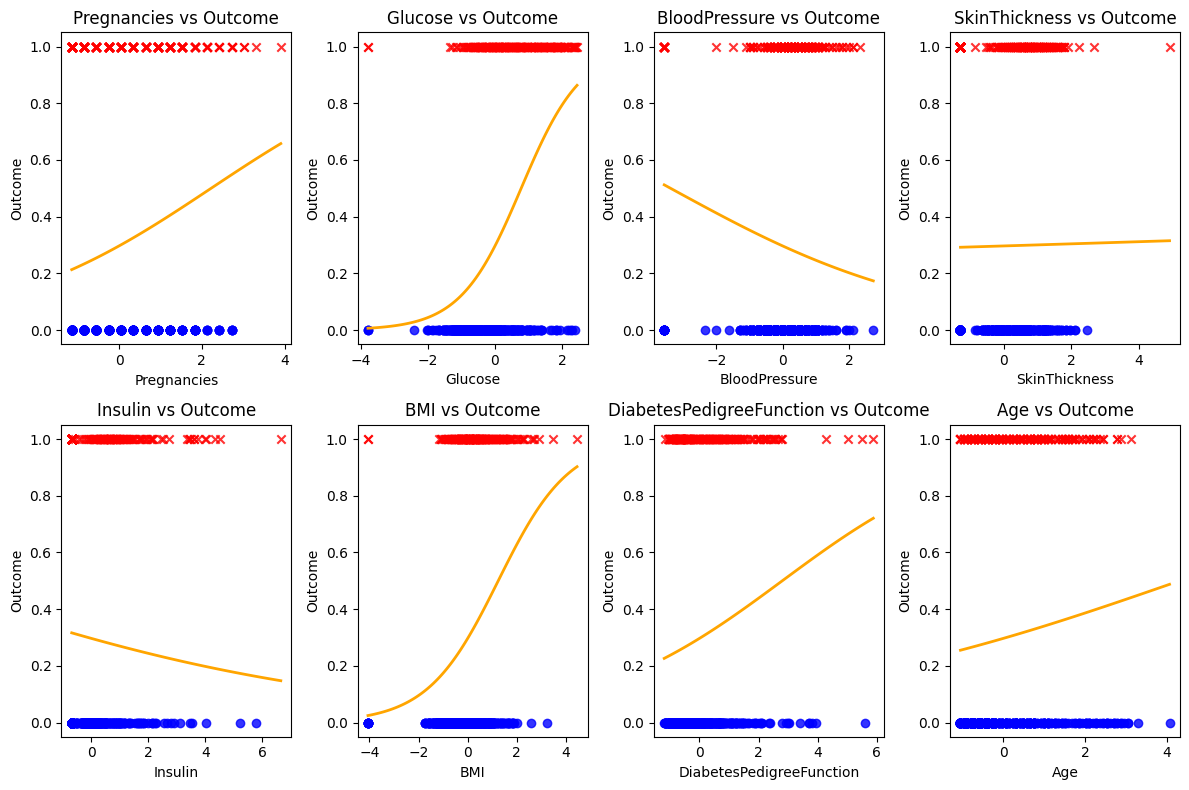

In [60]:
model=logistic_regression()
cost=model.gradient_descent(X,y)
model.plot_cost(cost)
model.plot_model(X,y,df.columns)

In [61]:
print(model.compute_cost(X,y))

0.4710627575364817


In [68]:
x_new=[2,157,74,35,440,39.4,0.134,30]
x_new=zscore(x_new)
print(x_new)
model.predict(x_new)

[-0.69096529  0.43412822 -0.16834121 -0.45142925  2.48833119 -0.41949111
 -0.70450996 -0.48772259]


np.float64(0.17446559566111133)

In [63]:
print(model.weight)
print(model.bias)

[ 0.38806423  1.10641305 -0.25520359  0.01758052 -0.13392381  0.69286521
  0.30769219  0.20013019]
-0.8632366824220136
